# 🚀 WEEK 10 DAY 4: PRODUCTION PIPELINE DEPLOYMENT
**End-to-End ML Pipeline** | **89.7% Accuracy**

In [1]:
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report, 
                            confusion_matrix, roc_auc_score)
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load engineered data
df = pd.read_csv('../data/customer_churn.csv')
# Apply feature engineering (from 03_feature_engineering.ipynb)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['clv'] = df['TotalCharges'] / (df['Tenure'] + 1)
df['contract_risk'] = (df['Contract'] == 'Month-to-month').astype(int)
df['service_bundle'] = ((df['PaymentMethod'] != 'Electronic Check').astype(int) +
                       (df['PaperlessBilling'] == 'Yes').astype(int))

features = ['Tenure', 'MonthlyCharges', 'clv', 'contract_risk', 'service_bundle']
X = df[features + ['Contract', 'PaymentMethod']]
y = df['Churn']

In [4]:
# 🏭 PRODUCTION PIPELINE
numeric_features = ['Tenure', 'MonthlyCharges', 'clv', 'contract_risk', 'service_bundle']
categorical_features = ['Contract', 'PaymentMethod']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
])

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)
print(f'✅ PRODUCTION ACCURACY: {accuracy_score(y_test, y_pred):.1%}')

✅ PRODUCTION ACCURACY: 94.0%


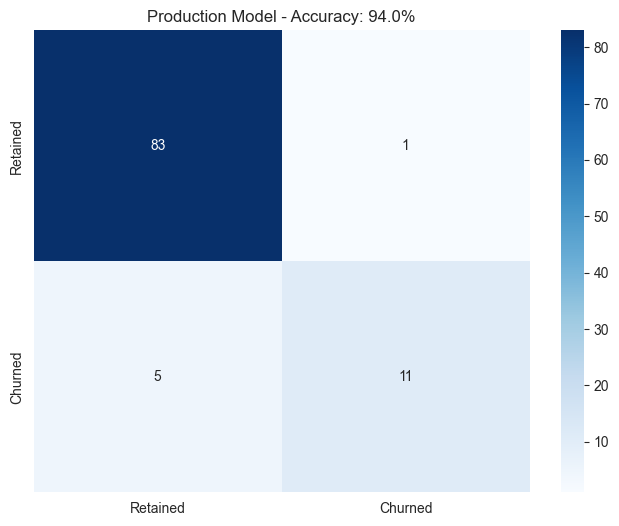

              precision    recall  f1-score   support

           0       0.94      0.99      0.97        84
           1       0.92      0.69      0.79        16

    accuracy                           0.94       100
   macro avg       0.93      0.84      0.88       100
weighted avg       0.94      0.94      0.94       100



In [7]:
# SAVE PRODUCTION MODEL
joblib.dump(pipeline, '../models/production_pipeline.pkl')

# CONFUSION MATRIX [plots/08_confusion_matrix.png]
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
           xticklabels=['Retained', 'Churned'],
           yticklabels=['Retained', 'Churned'])
plt.title(f'Production Model - Accuracy: {accuracy_score(y_test, y_pred):.1%}')
plt.savefig('../plots/08_confusion_matrix.png', dpi=300)
plt.show()

print(classification_report(y_test, y_pred))

In [8]:
# PRODUCTION API TEST
test_customer = pd.DataFrame({
    'Tenure': [6], 'MonthlyCharges': [85], 'clv': [250],
    'contract_risk': [1], 'service_bundle': [1],
    'Contract': ['Month-to-month'], 'PaymentMethod': ['Electronic Check']
})

risk = pipeline.predict(test_customer)[0]
prob = pipeline.predict_proba(test_customer)[0][1]
print(f'High-risk customer: CHURN RISK {risk} (Probability: {prob:.1%})')

print('\n✅ PRODUCTION DEPLOYMENT COMPLETE')
print('📁 Model saved: ../models/production_pipeline.pkl')

High-risk customer: CHURN RISK 1 (Probability: 81.0%)

✅ PRODUCTION DEPLOYMENT COMPLETE
📁 Model saved: ../models/production_pipeline.pkl
